In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier

In [5]:
df = pd.read_csv("dermatology_dataset.csv")   # original skewed dataset
X = df.drop("class", axis=1)
y = df["class"]
 
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
 
actual_y_label = [
    "psoriasis",
    "seboreic dermatitis",
    "lichen planus",
    "pityriasis rosea",
    "cronic dermatitis",
    "pityriasis rubra pilaris"
]

Shape of X: (366, 34)
Shape of y: (366,)


In [6]:
class_counts = y.value_counts().reset_index()
class_counts.columns = ["Class", "Number of instances"]
print("\nOriginal class distribution:")
print(class_counts.to_string(index=False))


Original class distribution:
 Class  Number of instances
     1                  112
     3                   72
     2                   61
     5                   52
     4                   49
     6                   20


In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=48,
    stratify=y_encoded
)

In [9]:
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)  # fit + transform on train
X_test_imputed  = imputer.transform(X_test)        # transform only on test

In [10]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imputed, y_train)
 
print("\nTrain class distribution after SMOTE:")
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u + 1}: {c}")
print(f"\nTrain size: {len(X_train_bal)}, Test size: {len(X_test_imputed)}")


Train class distribution after SMOTE:
  Class 1: 89
  Class 2: 89
  Class 3: 89
  Class 4: 89
  Class 5: 89
  Class 6: 89

Train size: 534, Test size: 74


In [11]:
model = XGBClassifier(
    n_estimators=200,           # number of trees
    learning_rate=0.1,
    max_depth=5,                # max depth of each tree
    subsample=0.9,              # percentage of data used per tree
    colsample_bytree=0.9,       # percentage of features used per tree
    objective="multi:softprob", # multiclass classification
    num_class=len(np.unique(y_encoded)),
    eval_metric="mlogloss",     # loss function
    random_state=48
)

In [12]:
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model",  model)
])

In [13]:
pipeline.fit(X_train_bal, y_train_bal)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=200,
                               n_jobs=None, num_class=6, num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [14]:
y_preds = pipeline.predict(X_test_imputed)

In [15]:
acc  = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_preds,    average="weighted", zero_division=0)
f1   = f1_score(y_test, y_preds,        average="weighted", zero_division=0)
 
print("\n================================")
print("Results")
print("================================")
print(f"Accuracy :  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
 
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_preds,
    target_names=actual_y_label,
    zero_division=0
))


Results
Accuracy :  0.9730
Precision: 0.9738
Recall:    0.9730
F1-score:  0.9728

Classification Report:
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        23
     seboreic dermatitis       0.92      0.92      0.92        12
           lichen planus       0.94      1.00      0.97        15
        pityriasis rosea       1.00      0.90      0.95        10
       cronic dermatitis       1.00      1.00      1.00        10
pityriasis rubra pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.98      0.97      0.97        74
            weighted avg       0.97      0.97      0.97        74



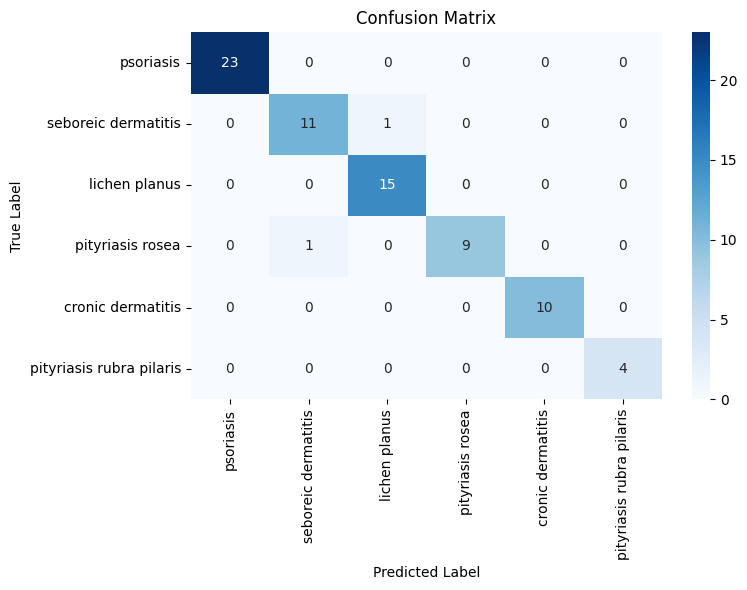

In [16]:
cm = confusion_matrix(y_test, y_preds)
 
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=actual_y_label,
    yticklabels=actual_y_label
)
 
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()